/var/folders/xs/llnz2_gn4fsfwjd4c0prr1w00000gp/T/ipykernel_76776/1518157261.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["studyType", "maf_bin"])["PAV_int"]


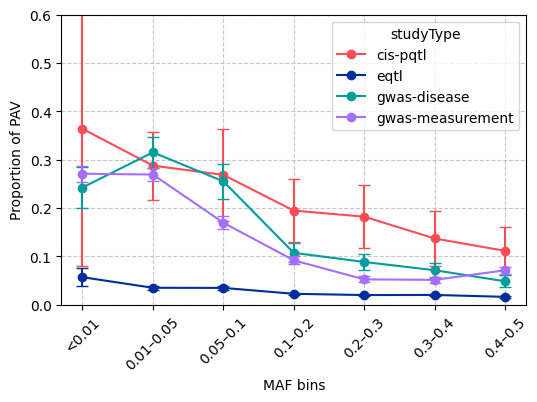

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

maf_vep_dataset_all = pd.read_csv("figure_2_b.csv")  # ex-for_figure_2_part_1.csv

# df = maf_vep_dataset_all
df = maf_vep_dataset_all.copy()
df["PAV_int"] = df["PAV"].astype(int)

# Определяем интервалы
bins = [0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
labels = ["<0.01", "0.01–0.05", "0.05–0.1", "0.1–0.2", "0.2–0.3", "0.3–0.4", "0.4–0.5"]

df["maf_bin"] = pd.cut(df["value"], bins=bins, labels=labels, include_lowest=True)

# Группируем по studyType + maf_bin
bin_stats = df.groupby(["studyType", "maf_bin"])["PAV_int"].agg(["mean", "count", "sum"]).reset_index()
bin_stats.rename(columns={"mean": "p", "count": "n", "sum": "n_pav"}, inplace=True)

# SE и доверительные интервалы
bin_stats["SE"] = np.sqrt(bin_stats["p"] * (1 - bin_stats["p"]) / bin_stats["n"])
bin_stats["CI_lower"] = (bin_stats["p"] - 1.96 * bin_stats["SE"]).clip(0, 1)
bin_stats["CI_upper"] = (bin_stats["p"] + 1.96 * bin_stats["SE"]).clip(0, 1)

colors = {"cis-pqtl": "#fa4d56", "eqtl": "#002d9c", "gwas-disease": "#009d9a", "gwas-measurement": "#a56eff"}

plt.figure(figsize=(6, 5))
plt.subplots_adjust(bottom=0.3)
for study, sub in bin_stats.groupby("studyType"):
    color = colors.get(study, "black")  # fallback to black if studyType not in dict
    # Line + markers
    plt.plot(sub["maf_bin"], sub["p"], marker="o", linestyle="-", label=study, color=color)
    # CI as error bars
    plt.errorbar(sub["maf_bin"], sub["p"], yerr=1.96 * sub["SE"], fmt="none", capsize=4, color=color)


plt.xlabel("MAF bins")
plt.ylabel("Proportion of PAV")
# plt.title("PAV proportion by MAF bins (with 95% CI) per studyType")
plt.xticks(rotation=45)
plt.ylim(0, 0.6)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(title="studyType")
plt.show()

[0.025, 0.075, 0.125, 0.175, 0.225, 0.275, 0.325, 0.375, 0.425, 0.475]


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/plotnine/themes/themeable.py:2490: FutureWarning: Themeable 'axis_ticks_direction' is deprecated andwill be removed in a future version. Use +ve or -ve values of the axis_ticks_lengthto affect the direction of the ticks.
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/plotnine/themes/themeable.py:2518: FutureWarning: Themeable 'axis_ticks_direction' is deprecated andwill be removed in a future version. Use +ve/-ve/complex values of the axis_ticks_lengthto affect the direction of the ticks.


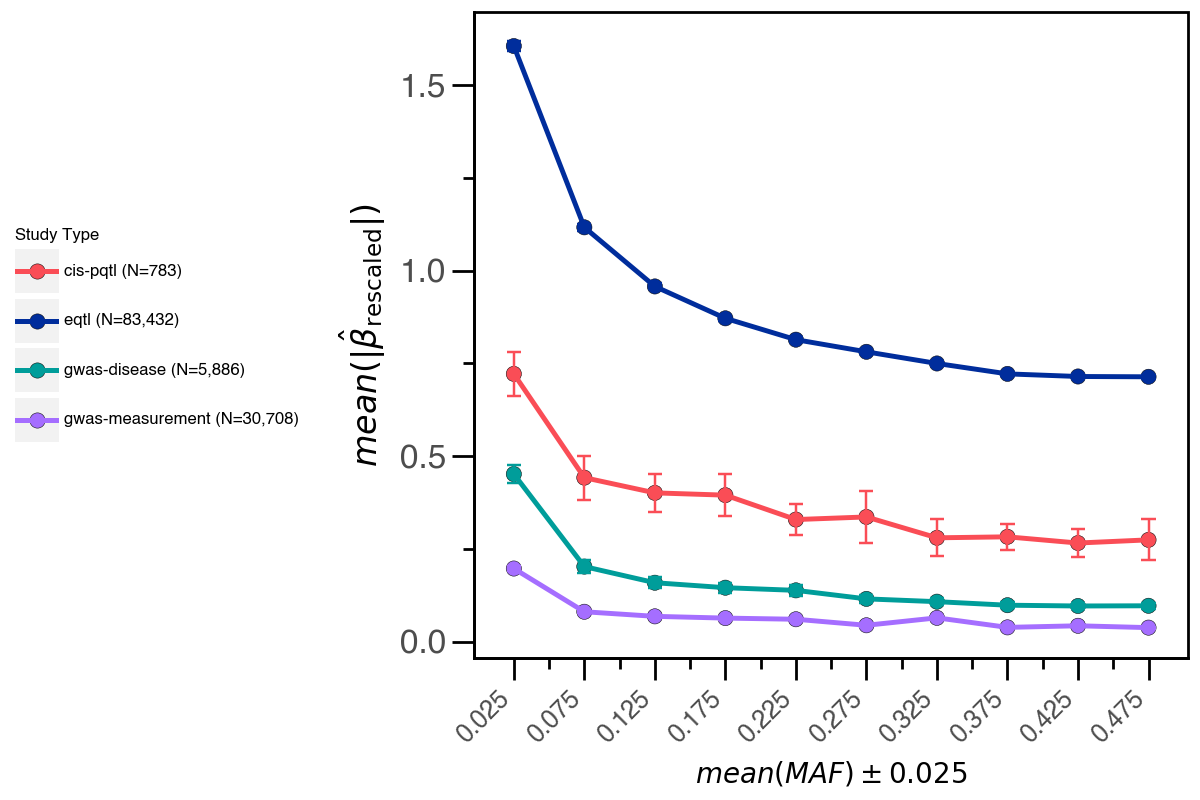

In [ ]:
import plotnine as pn

# Define colors (from OpenTargetsTheme.categorical_dark_colors)
categorical_dark_colors = [
    "#fa4d56",
    "#002d9c",
    "#009d9a",
    "#a56eff",
    "#005d5d",
    "#570408",
    "#ee538b",
    "#012749",
    "#6929c4",
    "#9f1853",
    "#198038",
    "#b28600",
    "#8a3800",
    "#1192e8",
]

# Define a simple categorical theme function


def categorical_theme(REM=10):
    return pn.theme(
        axis_title=pn.element_text(size=REM, family="sans-serif"),
        axis_ticks_direction="out",
        axis_ticks=pn.element_line(color="black"),
        axis_ticks_length_major=8,
        axis_ticks_length_minor=4,
        axis_line=pn.element_line(color="black"),
        panel_grid_major=pn.element_blank(),
        panel_grid_minor=pn.element_blank(),
        panel_background=pn.element_rect(fill="white"),
        axis_text_x=pn.element_text(size=REM * 1.5, family="sans-serif", rotation=45, va="top", ha="right"),
        axis_text_y=pn.element_text(size=REM * 2.0, family="sans-serif"),
        axis_title_y=pn.element_text(size=REM * 2.0, family="sans-serif"),
        panel_border=pn.element_rect(color="black", fill=None),
        figure_size=(REM / 2, REM / 1.5),
        legend_position=(0.4, 0.8),
        legend_title=pn.element_text(size=REM),
        legend_text=pn.element_text(size=REM),
        legend_direction="vertical",
        legend_box_background=pn.element_rect(color="black", size=1),
    )


data = pd.read_csv("figure_2_a.csv")  # ex-for_figure_2_part_2.csv

study_type_totals = data.groupby("studyType")["totalInBucket"].sum()
totals_map = {cat: f"{cat} (N={study_type_totals[cat]:,})" for cat in study_type_totals.index}
data["totals"] = data["studyType"].map(totals_map)
labels = data.drop_duplicates(subset=["studyType", "totals"])
REM = 10
breaks = [x for x in data["midPoint"].unique()]
print(breaks)
plot2 = (
    pn.ggplot(
        data,
        pn.aes(x="midPoint", y="meanAbsEstimatedBeta", fill="studyType"),
    )
    # + pn.geom_col(position="dodge")
    + pn.geom_point(pn.aes(fill="studyType"), stroke=0.1, size=3)
    + pn.geom_errorbar(
        pn.aes(
            ymin="meanAbsEstimatedBeta - intervalAbsEstimatedBeta",
            ymax="meanAbsEstimatedBeta + intervalAbsEstimatedBeta",
            x="midPoint",
            color="studyType",
        ),
        width=0.01,
        # position=pn.position_dodge(width=0.9),
    )
    + pn.labs(
        # title="Proportion of lead variant effects in replicated credible sets",
        x=r"$mean(MAF)\pm{0.025}$",
        y=r"$mean(|\hat{\beta}_{\mathrm{rescaled}}|)$",
    )
    + categorical_theme(REM=6)
    + pn.theme(axis_title_x=pn.element_text(size=10))
    # Remove the legend
    # + pn.facet_wrap(nrow=3, facets="studyType", scales="free_y")
    + pn.geom_line(
        pn.aes(x="midPoint", y="meanAbsEstimatedBeta", group="studyType", color="studyType"),
        size=1,
    )
    + pn.scale_fill_manual(
        values=categorical_dark_colors,
        name="Study Type",
        labels=totals_map,
    )
    + pn.scale_color_manual(
        values=categorical_dark_colors,
        name="Study Type",
        labels=totals_map,
    )
    + pn.scale_x_continuous(
        breaks=[x for x in data["midPoint"].unique()],
        labels=[x for x in data["midPoint"].unique()],
    )
    # + pn.theme(legend_position=(0.70, 0.82))
    + pn.theme(legend_position="left", figure_size=(6, 4))
)
plot2

/var/folders/xs/llnz2_gn4fsfwjd4c0prr1w00000gp/T/ipykernel_81904/2465308094.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


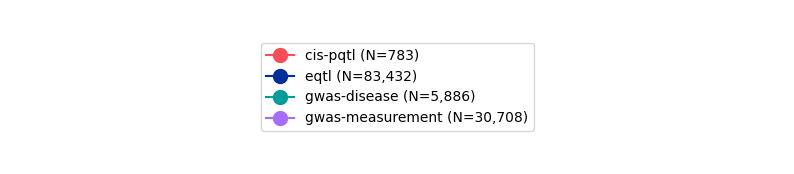

In [6]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(10, 2))
ax = fig.add_subplot(111)

# Create dummy handles (like plot markers or lines) and labels
names = ["cis-pqtl", "eqtl", "gwas-disease", "gwas-measurement"]
colors = categorical_dark_colors[: len(names)]
handles = [
    Line2D(
        [0], [0], marker="o", color=color, linestyle="-", label=totals_map[name], markerfacecolor=color, markersize=10
    )
    for name, color in zip(names, colors)
]

labels = [h.get_label() for h in handles]

ax.axis("off")  # Hide the axis

# Add the legend to the axis
legend = ax.legend(handles=handles, labels=labels, loc="center", frameon=True)
fig.show()

In [12]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as f
from pyspark.sql import Window

spark = SparkSession.builder.appName("Gentropy").config("spark.driver.memory", "40G").getOrCreate()

nc_dataset = spark.read.parquet(
    "/Users/polina/Gentropy-manuscript/chapters/03-manuscript-figures/figure_2/nc_dataset_filtered"
)
nc_dataset.count()

459516

In [13]:
# Extract only GWAS
gwas_dataset = (
    nc_dataset.filter(f.col("studyType").isin("gwas-disease")).select(
        "variantId",
        "intervalType",
        "estimatedBeta",
        "estimatedSE",
        "studyType",
        "consequenceOntologyTerms",
        "MAF",
        "studyLocusId",
        "geneId",
        "biosampleId",
        "diseaseIds",
        "consequence",
    )
).cache()
gwas_dataset.count()

gwas_dataset.count()

# Extract only GWAS
gwas_measurement = (
    nc_dataset.filter(f.col("studyType").isin("gwas-measurement")).select(
        "variantId",
        "intervalType",
        "estimatedBeta",
        "estimatedSE",
        "studyType",
        "consequenceOntologyTerms",
        "MAF",
        "studyLocusId",
        "geneId",
        "biosampleId",
        "diseaseIds",
        "consequence",
    )
).cache()
gwas_measurement.count()

# Keep only the row with highest estimatedBeta for each variantId, diseaseIds, intervalType combination
# from pyspark.sql.window import Window

# window_spec = Window.partitionBy("variantId", "diseaseIds", "intervalType").orderBy(f.desc(f.abs("estimatedBeta")))
# gwas_measurement = gwas_measurement.withColumn("row_num", f.row_number().over(window_spec)).filter(f.col("row_num") == 1).drop("row_num")
# gwas_measurement.count()

# Extract merged dataset
molQTLs_dataset = (
    nc_dataset.filter(f.col("studyType").isin("cis-pqtl", "eqtl")).select(
        "variantId",
        "intervalType",
        "estimatedBeta",
        "estimatedSE",
        "studyType",
        "consequenceOntologyTerms",
        "MAF",
        "studyLocusId",
        "geneId",
        "biosampleId",
        "diseaseIds",
        "consequence",
    )
).cache()
molQTLs_dataset.count()

merged_dataset = molQTLs_dataset.union(gwas_dataset).union(gwas_measurement).cache()
merged_dataset.count()

# Combine gwas_measurement and gwas_dataset (equivalent to rbind in R)
combined_gwas_dataset = gwas_measurement.union(gwas_dataset)
combined_gwas_dataset.count()

103841

In [14]:
beta = "\u03b2"
hat = "\u0302"
plus_minus = "\u00b1"


data_diseases = (
    gwas_dataset.groupBy("consequence", "studyType")
    .agg(
        f.mean(f.abs("estimatedBeta")).alias("meanAbsEstimatedBeta"),
        f.stddev(f.abs("estimatedBeta")).alias("stddevAbsEstimatedBeta"),
        (f.lit(1.96) * f.stddev(f.abs("estimatedBeta")) / f.sqrt(f.count(f.abs("estimatedBeta")))).alias(
            "intervalAbsEstimatedBeta"
        ),
        f.count(f.col("variantId")).alias("variantCount"),
    )
    .withColumn(
        "label",
        f.concat_ws(
            " / ",
            "consequence",
            f.concat_ws("=", f.lit("N"), "variantCount"),
            f.concat_ws(
                plus_minus,
                f.concat_ws("=", f.lit(beta + hat), f.round("meanAbsEstimatedBeta", 3)),
                f.round("intervalAbsEstimatedBeta", 3),
            ),
        ),
    )
    .toPandas()
)
data_diseases

,consequence,studyType,meanAbsEstimatedBeta,stddevAbsEstimatedBeta,intervalAbsEstimatedBeta,variantCount,label
0,protein_altering,gwas-disease,0.316452,0.378044,0.016235,2083,protein_altering / N=2083 / β̂=0.316±0.016
1,intergenic,gwas-disease,0.204160,0.267710,0.011238,2180,intergenic / N=2180 / β̂=0.204±0.011
2,enhancer,gwas-disease,0.166060,0.210047,0.009174,2014,enhancer / N=2014 / β̂=0.166±0.009
3,promoter,gwas-disease,0.151842,0.181538,0.019891,320,promoter / N=320 / β̂=0.152±0.02
4,intragenic,gwas-disease,0.186521,0.239477,0.006011,6097,intragenic / N=6097 / β̂=0.187±0.006


In [15]:
beta = "\u03b2"
hat = "\u0302"
plus_minus = "\u00b1"


data_measurement = (
    gwas_measurement.groupBy("consequence", "studyType")
    .agg(
        f.mean(f.abs("estimatedBeta")).alias("meanAbsEstimatedBeta"),
        f.stddev(f.abs("estimatedBeta")).alias("stddevAbsEstimatedBeta"),
        (f.lit(1.96) * f.stddev(f.abs("estimatedBeta")) / f.sqrt(f.count(f.abs("estimatedBeta")))).alias(
            "intervalAbsEstimatedBeta"
        ),
        f.count(f.col("variantId")).alias("variantCount"),
    )
    .withColumn(
        "label",
        f.concat_ws(
            " / ",
            "consequence",
            f.concat_ws("=", f.lit("N"), "variantCount"),
            f.concat_ws(
                plus_minus,
                f.concat_ws("=", f.lit(beta + hat), f.round("meanAbsEstimatedBeta", 3)),
                f.round("intervalAbsEstimatedBeta", 3),
            ),
        ),
    )
    .toPandas()
)
data_measurement

,consequence,studyType,meanAbsEstimatedBeta,stddevAbsEstimatedBeta,intervalAbsEstimatedBeta,variantCount,label
0,enhancer,gwas-measurement,0.073183,0.129945,0.002227,13082,enhancer / N=13082 / β̂=0.073±0.002
1,intergenic,gwas-measurement,0.080123,0.146654,0.002217,16809,intergenic / N=16809 / β̂=0.08±0.002
2,intragenic,gwas-measurement,0.085954,0.156812,0.001471,43628,intragenic / N=43628 / β̂=0.086±0.001
3,promoter,gwas-measurement,0.100853,0.228479,0.008072,3078,promoter / N=3078 / β̂=0.101±0.008
4,protein_altering,gwas-measurement,0.160632,0.245919,0.003996,14550,protein_altering / N=14550 / β̂=0.161±0.004


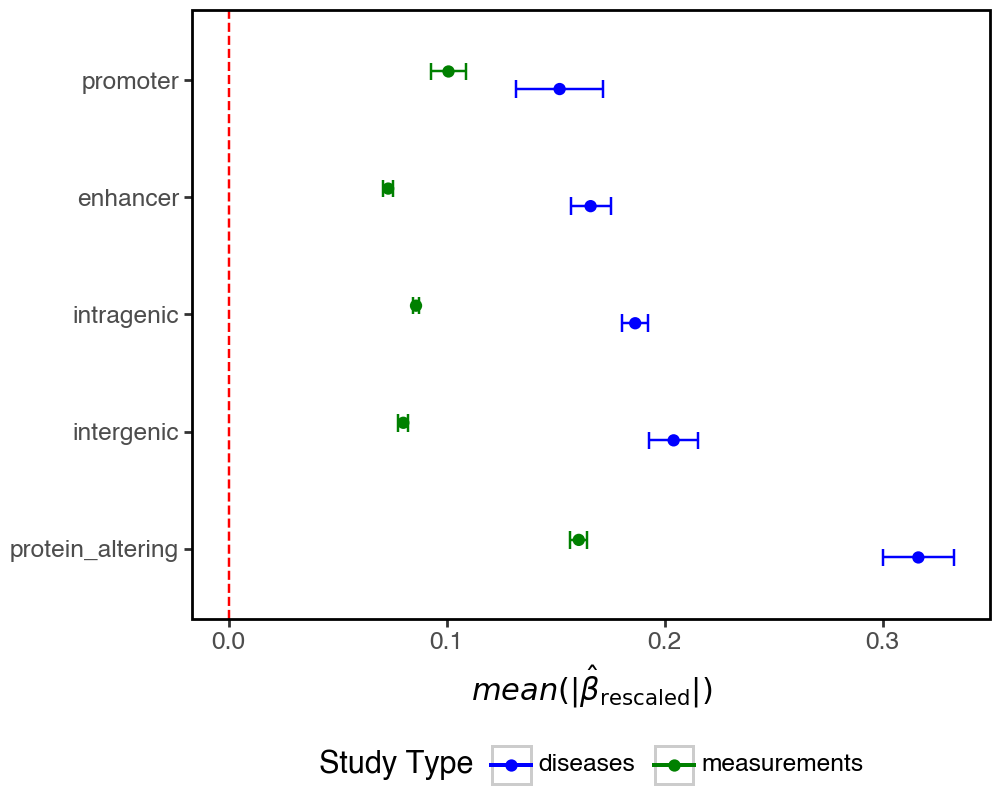

In [18]:
# Combine both datasets for plotting
data_diseases_labeled = data_diseases.copy()
data_diseases_labeled["study_category"] = "diseases"

data_measurement_labeled = data_measurement.copy()
data_measurement_labeled["study_category"] = "measurements"

# Combine the datasets
combined_data = pd.concat([data_diseases_labeled, data_measurement_labeled], ignore_index=True)

# Create ordering based on measurements meanAbsEstimatedBeta (highest to lowest)
measurement_order = data_diseases_labeled.sort_values("meanAbsEstimatedBeta", ascending=False)["consequence"].tolist()

# Convert consequence to categorical with custom order
combined_data["consequence"] = pd.Categorical(combined_data["consequence"], categories=measurement_order, ordered=True)

# Create combined plot
combined_plot = (
    pn.ggplot(combined_data)
    + pn.geom_point(
        pn.aes(x="consequence", y="meanAbsEstimatedBeta", color="study_category"),
        size=1.5,
        position=pn.position_dodge(width=0.3),
    )
    + pn.geom_errorbar(
        pn.aes(
            x="consequence",
            ymin="meanAbsEstimatedBeta - intervalAbsEstimatedBeta",
            ymax="meanAbsEstimatedBeta + intervalAbsEstimatedBeta",
            color="study_category",
        ),
        width=0.3,
        position=pn.position_dodge(width=0.3),
    )
    + pn.scale_color_manual(values={"measurements": "green", "diseases": "blue"}, name="Study Type")
    + pn.theme_bw()
    + pn.theme(
        axis_text_y=pn.element_text(rotation=0),
        legend_position="bottom",
        figure_size=(5, 4),
        panel_grid=pn.element_blank(),
        panel_border=pn.element_rect(color="black", fill=None),
    )
    + pn.labs(x="", y=r"$mean(|\hat{\beta}_{\mathrm{rescaled}}|)$")
    + pn.geom_hline(pn.aes(yintercept=0), linetype="dashed", color="red", size=0.5)
    + pn.coord_flip()
)
combined_plot

In [19]:
data2 = (
    merged_dataset.withColumn(
        "totalCountPerStudyType", f.count(f.col("variantId")).over(Window.partitionBy("studyType"))
    )
    .withColumn(
        "totalCountPerStudyTypeAndConsequence",
        f.count(f.col("variantId")).over(Window.partitionBy("studyType", "consequence")),
    )
    .withColumn("totalCountPerConsequence", f.count(f.col("variantId")).over(Window.partitionBy("consequence")))
    .withColumn("percentage", f.col("totalCountPerStudyTypeAndConsequence") / f.col("totalCountPerStudyType"))
    .drop_duplicates(["consequence", "studyType", "totalCountPerStudyTypeAndConsequence", "totalCountPerStudyType"])
    .withColumn(
        "cumulativeSum",
        f.sum(f.col("percentage")).over(Window.partitionBy("studyType").orderBy(f.desc("totalCountPerConsequence"))),
    )
    .withColumn("pointLabel", f.concat_ws("", f.format_number(f.col("percentage") * 100, 2), f.lit("%")))
    .withColumn("pointLabelPosition", f.col("cumulativeSum") - (f.col("percentage") / 2))
    .withColumn("fillLabel", f.col("consequence"))
    .select(
        "pointLabel",
        "pointLabelPosition",
        "fillLabel",
        "percentage",
        "consequence",
        "studyType",
        "totalCountPerStudyTypeAndConsequence",
        "totalCountPerStudyType",
        "totalCountPerConsequence",
        "cumulativeSum",
    )
    .orderBy("totalCountPerStudyTypeAndConsequence", ascending=False)
    .toPandas()
)
data2.sort_values(by=["studyType", "totalCountPerConsequence"], ascending=[True, False], inplace=True)
data2["label_to_show"] = data2.apply(lambda row: f"{row['pointLabel']}" if row["percentage"] > 0.05 else "", axis=1)
data2

,pointLabel,pointLabelPosition,fillLabel,percentage,consequence,studyType,totalCountPerStudyTypeAndConsequence,totalCountPerStudyType,totalCountPerConsequence,cumulativeSum,label_to_show
14,41.89%,0.209450,intragenic,0.418901,intragenic,cis-pqtl,625,1492,250448,0.418901,41.89%
17,17.16%,0.504692,enhancer,0.171582,enhancer,cis-pqtl,256,1492,69977,0.590483,17.16%
19,10.86%,0.644772,intergenic,0.108579,intergenic,cis-pqtl,162,1492,63833,0.699062,10.86%
18,11.80%,0.758043,promoter,0.117962,promoter,cis-pqtl,176,1492,44543,0.817024,11.80%
16,18.30%,0.908512,protein_altering,0.182976,protein_altering,cis-pqtl,273,1492,30715,1.000000,18.30%
0,56.50%,0.282478,intragenic,0.564957,intragenic,eqtl,200098,354183,250448,0.564957,56.50%
1,15.42%,0.642071,enhancer,0.154228,enhancer,eqtl,54625,354183,69977,0.719185,15.42%
2,12.62%,0.782262,intergenic,0.126155,intergenic,eqtl,44682,354183,63833,0.845340,12.62%
4,11.57%,0.903176,promoter,0.115672,promoter,eqtl,40969,354183,44543,0.961012,11.57%
7,3.90%,0.980506,protein_altering,0.038988,protein_altering,eqtl,13809,354183,30715,1.000000,


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/plotnine/themes/themeable.py:2490: FutureWarning: Themeable 'axis_ticks_direction' is deprecated andwill be removed in a future version. Use +ve or -ve values of the axis_ticks_lengthto affect the direction of the ticks.
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/plotnine/themes/themeable.py:2518: FutureWarning: Themeable 'axis_ticks_direction' is deprecated andwill be removed in a future version. Use +ve/-ve/complex values of the axis_ticks_lengthto affect the direction of the ticks.


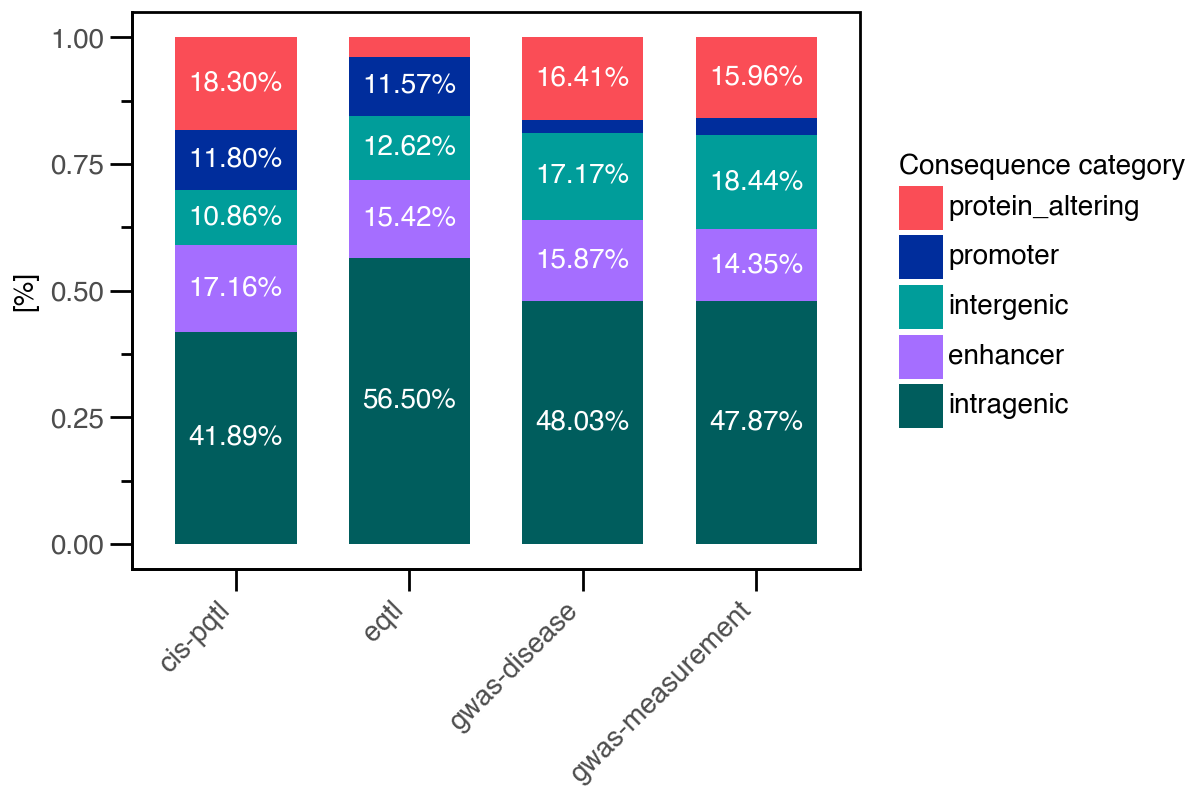

In [20]:
plot2 = (
    pn.ggplot(data2)
    + pn.geom_col(pn.aes(x="studyType", y="percentage", fill="reorder(fillLabel, totalCountPerConsequence)"), width=0.7)
    + categorical_theme(5)
    + pn.theme(figure_size=(6, 4))
    + pn.theme(
        axis_text_y=pn.element_text(rotation=0, hjust=1, size=10),
        axis_text_x=pn.element_text(size=10),
        legend_text=pn.element_text(size=10),
    )
    + pn.labs(x="", y="[%]", fill="Consequence category")
    + pn.theme(legend_title=pn.element_text(size=10, weight=50), legend_position="right")
    # Move the geom_text to point to the correct part of the bar
    # + pn.geom_text(pn.aes(label="%", y="percentage", x="studyType"), size=8, color="black")
    + pn.geom_text(pn.aes(label="label_to_show", y="pointLabelPosition", x="studyType"), size=10, color="white")
    + pn.scale_fill_manual(values=categorical_dark_colors)
)
plot2

In [ ]:
data2.to_csv("figure_2_c.csv", index=False)  # ex-data2_for_plot_c.csv
combined_data.to_csv("figure_2_d.csv", index=False)  # ex-combined_data_for_plot_d.csv